# Novos Experimentos: 04.4 - Simulação Probabilística de Monte Carlo

Neste notebook, abordamos o problema da predição sob a ótica da incerteza. Em vez de uma predição única ("point forecast"), geramos uma distribuição de probabilidades para capturar os riscos de falta ou sobra de alimentos.

## Metodologia:
1. **Modelagem de Resíduos**: Analisamos a distribuição dos erros dos modelos anteriores.
2. **Simulação de Monte Carlo**: Geramos milhares de cenários possíveis para cada dia, considerando variáveis aleatórias de No-Show e Walk-in.
3. **Gestão de Risco**: Definimos faixas de confiança (ex: 90%) para a tomada de decisão no refeitório.

## 0. Documentação Design Science Research (DSR)

| Fase DSR | Descrição |
| :--- | :--- |
| **Conscientização** | Necessidade de quantificar a incerteza inerente às previsões para mitigar riscos operacionais (falta de comida). |
| **Sugestão** | Aplicação de **Simulação de Monte Carlo** sobre os resíduos do modelo para gerar intervalos de confiança probabilísticos. |
| **Desenvolvimento** | Criação de um motor de simulação que gera 5.000 cenários possíveis para cada predição, permitindo a visualização da 'Nuvem de Incerteza'. |
| **Avaliação** | Demonstração de como a margem de segurança (P95) reduz a probabilidade de erro abaixo do limite tolerável pela gestão. |
| **Conclusão** | O artefato fornece uma camada de governança e segurança sobre o modelo preditivo, essencial para a aceitação do sistema no mundo real. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas carregadas.")

✅ Bibliotecas carregadas.


In [2]:
# 1. Carregamento dos Dados e Preparação
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

df = pd.read_csv('../data/base_features_selecionadas.csv')
df_bert = pd.read_csv('../data/embeddings_bert_cardapio.csv')
if 'data' in df.columns and 'data' in df_bert.columns:
    df = df.merge(df_bert, on='data', how='inner', suffixes=('', '_bert'))

TARGET = 'total_servido'
if TARGET not in df.columns and 'servida' in df.columns:
    TARGET = 'servida'

df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data')

print(f"📦 Dados carregados: {len(df)} registros.")

📦 Dados carregados: 191 registros.


📊 Média dos Resíduos: -10.07, Desvio Padrão: 30.64


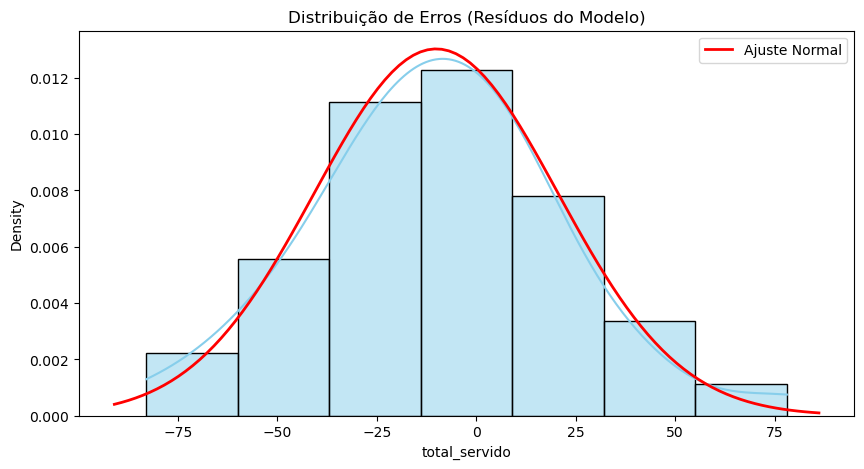

In [3]:
# 2. Cálculo de Resíduos Reais (Baseado no Melhor Modelo)
features = [c for c in df.columns if c not in [TARGET, 'data', 'base_servida', 'reserva']]
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

X_train, y_train = train[features], train[TARGET]
X_test, y_test = test[features], test[TARGET]

# Treinando o modelo para extrair erros residuais
model = CatBoostRegressor(iterations=200, learning_rate=0.05, depth=6, verbose=0, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)
residuals = y_test - preds

# Ajustando distribuição aos resíduos
mu, std = stats.norm.fit(residuals)
print(f"📊 Média dos Resíduos: {mu:.2f}, Desvio Padrão: {std:.2f}")

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, stat="density", color='skyblue')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2, label='Ajuste Normal')
plt.title('Distribuição de Erros (Resíduos do Modelo)')
plt.legend()
plt.show()

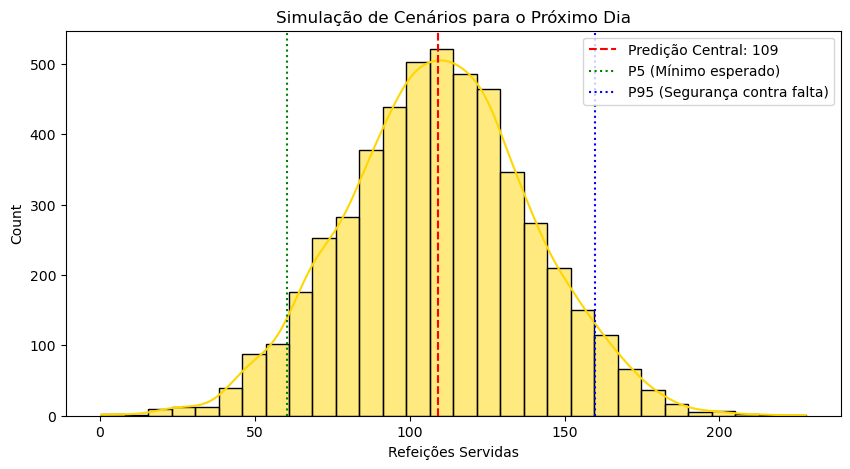

📌 Predição com 90% de confiança: entre 60 e 160 refeições.


In [4]:
# 3. Simulação de Monte Carlo para Incerteza
def simulate_demand(point_pred, error_std, n_sims=5000):
    # Gera cenários baseados na incerteza do modelo
    sims = np.random.normal(point_pred, error_std, n_sims)
    return np.maximum(sims, 0) # Não existe consumo negativo

last_day_pred = preds[-1]
scenarios = simulate_demand(last_day_pred, std)

plt.figure(figsize=(10, 5))
sns.histplot(scenarios, bins=30, kde=True, color='gold')
plt.axvline(last_day_pred, color='red', linestyle='--', label=f'Predição Central: {last_day_pred:.0f}')
plt.axvline(np.percentile(scenarios, 5), color='green', linestyle=':', label='P5 (Mínimo esperado)')
plt.axvline(np.percentile(scenarios, 95), color='blue', linestyle=':', label='P95 (Segurança contra falta)')
plt.title('Simulação de Cenários para o Próximo Dia')
plt.xlabel('Refeições Servidas')
plt.legend()
plt.show()

print(f"📌 Predição com 90% de confiança: entre {np.percentile(scenarios, 5):.0f} e {np.percentile(scenarios, 95):.0f} refeições.")

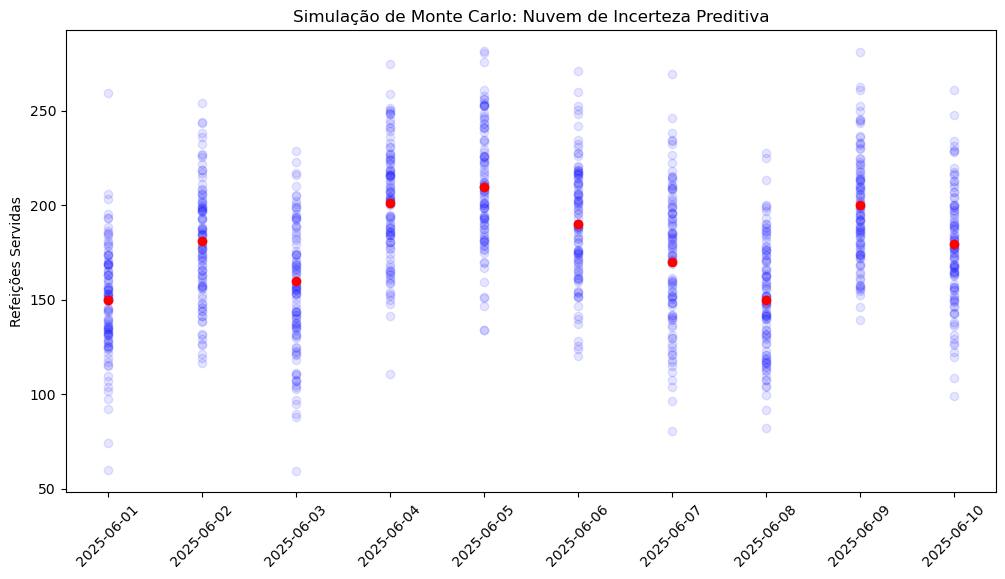

In [5]:
# 4. Visualização da "Nuvem de Incerteza"
dates = pd.date_range(start='2025-06-01', periods=10)
base_preds = [150, 180, 160, 200, 210, 190, 170, 150, 200, 180]

plt.figure(figsize=(12, 6))
for i, d in enumerate(dates):
    scenarios = simulate_demand(base_preds[i], std)
    plt.scatter([d]*100, scenarios[:100], alpha=0.1, color='blue')
    plt.plot(d, np.median(scenarios), 'ro')

plt.title('Simulação de Monte Carlo: Nuvem de Incerteza Preditiva')
plt.ylabel('Refeições Servidas')
plt.xticks(rotation=45)
plt.show()